## Python For Machine Learning Fall 2025
---
# NLP Introduction: Feature Extraction

# 1. Overview

In the field of NLP, the discussion of similar concepts like "feature," "embedding," and "description" involves two fundamental problems: one is document-level representation, and the other is word-level representation. How a document is represented depends greatly on how its words are represented.

We will first discuss document representation. Please note that we are not distinguishing between "words" and "tokens" here. This is only for simplicity; the actual unit in Natural Language Processing is the "token," but using "word" makes the explanation more intuitive.

# 2. Document Representation

Although Natural Language Processing (NLP) has many different applications, text classification is the most common and the one that connects most easily to our previous topics.
Early feature design focused mainly on classification problems. The most significant challenge was that most models, such as neural networks and logistic regression, only accept fixed-size inputs.

In [ ]:
data = {
        'text': [
            'This movie was fantastic! I loved every moment of it.',
            'What a terrible film, absolutely dreadful acting.',
            'It was okay, nothing special, just average.',
            'The best experience I have had in years, truly amazing.',
            'I hated it, complete waste of time and money.',
            'A truly captivating story and brilliant cinematography.',
            'So boring, I almost fell asleep multiple times.',
            'Highly recommended! Must watch for everyone.',
            'Mediocre at best, very predictable plot.',
            'Enjoyed the plot twists and character development.'
        ],
        'sentiment': [
            'positive', 'negative', 'neutral', 'positive', 'negative',
            'positive', 'negative', 'positive', 'neutral', 'positive'
        ]
    }

Although the database above is simple, it reminds us that we must "vectorize" text to apply our existing classification models to text classification tasks.

## 2.1 Bag-of-Words (BoW)

The BoW model is the simplest and most classic approach. It's called this because it treats each document as an unordered "bag" of its words, disregarding grammar and word order but keeping track of frequency.


The BoW algorithm includes the following steps:

1.  **Build a Vocabulary:** First, we look at our entire collection of documents (the "corpus") and find every unique word. This collection of unique words is called the **vocabulary**.
2.  **Create Vectors:** For each document, we create a vector. This vector will have one position (or dimension) for every single word in the vocabulary.
3.  **Count Occurrences:** We go through the document and, for each word, we put a `1` (or the number of times it appears) in its corresponding position in the vector. If a word from the vocabulary isn't in our document, it gets a `0`.



Let's see a simple example:

* **Document 1:** "The cat sat on the mat."
* **Document 2:** "The cat sat."

* **Vocabulary:** `{"the", "cat", "sat", "on", "mat"}` (5 unique words)
* **Vector for Doc 1:** `[2, 1, 1, 1, 1]` (since "the" appears twice)
* **Vector for Doc 2:** `[1, 1, 1, 0, 0]`

In scikit-learn, this is implemented using `CountVectorizer`.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

Our corpus of documents.

In [ ]:
corpus = [
    'The cat sat on the mat.',
    'The cat sat.',
    'The dog ate the food.'
]

Vectorize and view the results.

In [ ]:
vectorizer = CountVectorizer()

bow_matrix = vectorizer.fit_transform(corpus)

print("Vocabulary:")
print(vectorizer.get_feature_names_out())

print("\nBoW Matrix:")
print(bow_matrix.toarray())

Vocabulary:
['ate' 'cat' 'dog' 'food' 'mat' 'on' 'sat' 'the']

BoW Matrix:
[[0 1 0 0 1 1 1 2]
 [0 1 0 0 0 0 1 1]
 [1 0 1 1 0 0 0 2]]


## 2.2 Term Frequency-Inverse Document Frequency (TF-IDF)

A major weakness of BoW is that it treats all words equally. The word "**the**" will have a high count in almost every document, but it's not very *informative*. The word "**algorithm**" might only appear once, but it's highly informative.

We want a way to **reward important words** and **punish common, uninformative words**.

This is what TF-IDF does. It's a score calculated for every word in every document. It's composed of two parts:

### 2.2.1 Term Frequency (TF)

**"How often does this word appear in *this specific document*?"**

This is just like `CountVectorizer` (or sometimes it's normalized by dividing by the total number of words in the document).

* **Concept:** A word that appears many times in one document is likely important *for that document*.
* **Example:** In an article about "dogs", the word "dog" will have a high TF.

### 2.2.2 Inverse Document Frequency (IDF)

**"How rare is this word across *all documents* in the corpus?"**

This is the part that does the "punishing."

* **Concept:** We calculate a score that is **high** for rare words (like "algorithm") and **low** for common words (like "the", "is", "a").
* **Formula:** The basic idea is $\log(\frac{\text{Total Documents}}{\text{Documents containing the word}})$.
* Scikit-learn uses a slightly modified "smoothed" version to prevent division by zero and to avoid nullifying words that appear in all documents.



### 2.2.3 Putting it together: TF-IDF

The final **TF-IDF score** for a word in a document is simply:

$$
\text{TF-IDF} = \text{TF} \times \text{IDF}
$$

* **High TF-IDF:** A word gets a high score if it appears frequently in *one* document (high TF) **AND** is rare across all other documents (high IDF). These are the important, descriptive words.
* **Low TF-IDF:** A word gets a low score if it's very common across all documents (like "the", low IDF), even if it appears a lot in the current document (high TF).

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Let's use the same corpus as before
print("Corpus:", corpus, "\n")

# 1. Initialize the TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# 2. Fit and transform the corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus)

# 3. See the vocabulary (it should be the same)
print("Vocabulary:")
print(tfidf_vectorizer.get_feature_names_out())

# 4. See the resulting TF-IDF matrix
print("\nTF-IDF Matrix (Dense):")
print(tfidf_matrix.toarray())

Corpus: ['The cat sat on the mat.', 'The cat sat.', 'The dog ate the food.'] 

Vocabulary:
['ate' 'cat' 'dog' 'food' 'mat' 'on' 'sat' 'the']

TF-IDF Matrix (Dense):
[[0.         0.3564574  0.         0.         0.46869865 0.46869865
  0.3564574  0.55364194]
 [0.         0.61980538 0.         0.         0.         0.
  0.61980538 0.48133417]
 [0.4769856  0.         0.4769856  0.4769856  0.         0.
  0.         0.56343076]]


Notice how the values are no longer simple integers. The word "**the**" (column 6) has a *lower* score than words like "**mat**" (column 4) or "**dog**" (column 1), because "the" appears in all three documents (low IDF), while the others are more specific. This TF-IDF matrix is what we will feed into our machine learning models.

# 3. Visualzaion

Our TF-IDF vectors are high-dimensional (in our case, 7 dimensions). To visualize them, we need to reduce them down to 2 or 3 dimensions. **t-SNE (t-distributed Stochastic Neighbor Embedding)** is a very popular technique for this. t-SNE tries to find a 2D (or 3D) representation of the data that preserves the *local neighborhood* structure. In short, documents that have similar TF-IDF vectors should end up as points close to each other in the 2D plot.

Let's try it on a slightly larger, more distinct corpus.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

In [ ]:
text = data['text']
labels = data['sentiment']

Create TF-IDF vectors

In [ ]:
tfidf_vec = TfidfVectorizer()
tfidf_matrix = tfidf_vec.fit_transform(text)

Apply t-SNE to reduce to 2 dimensions.

In [ ]:
# perplexity must be less than n_samples. n_samples=6, so we'll use perplexity=3
tsne = TSNE(n_components=2, perplexity=3)
tsne_vectors = tsne.fit_transform(tfidf_matrix.toarray()) # .toarray() is needed

Plot the 2D vectors.

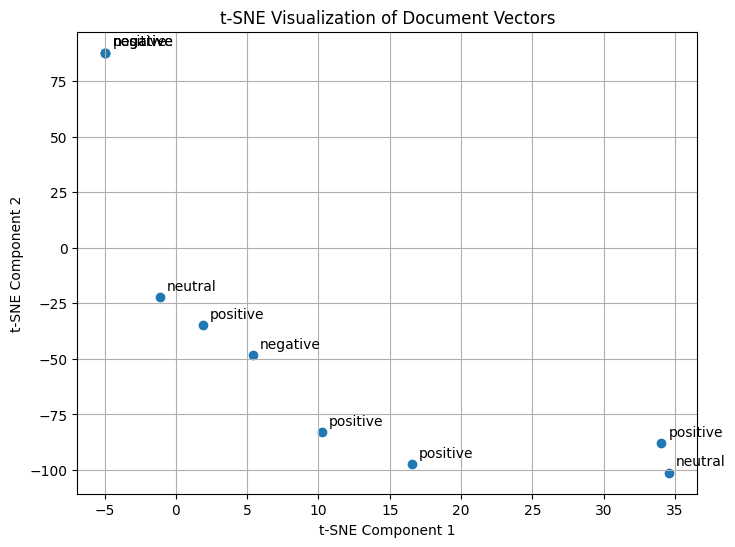

In [ ]:
x = tsne_vectors[:, 0]
y = tsne_vectors[:, 1]

plt.figure(figsize=(8, 6))

scatter = plt.scatter(x, y)

for i, label in enumerate(labels):
    plt.annotate(label, (x[i], y[i]), xytext=(5, 5), textcoords='offset points')

plt.title("t-SNE Visualization of Document Vectors")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()

# 4. Text Classification with scikit-learn

Let's use what we've solve a 'real' problem. We will use the `MLPClassifier` from `scikit-learn` to classify the `20newsgroups` dataset, using the TF-IDF feature.

Import necessary libaries.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Load the built-in dataset.

In [ ]:
newsgroups_train = fetch_20newsgroups(
    subset='train',
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    shuffle=True,
    random_state=42,
    remove=('headers', 'footers', 'quotes')
)

X_train = newsgroups_train.data
y_train = newsgroups_train.target  # Labels are 0-19

X_test = newsgroups_test.data
y_test = newsgroups_test.target

# Get the list of category names
target_names = newsgroups_train.target_names

print(f"Total categories: {len(target_names)}")
print(f"Training examples: {len(X_train)}")
print(f"Test examples: {len(X_test)}")

Total categories: 20
Training examples: 11314
Test examples: 7532


Apply TF-IDF vectorization.

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of training TF-IDF matrix: {X_train_tfidf.shape}")
print(f"Shape of test TF-IDF matrix: {X_test_tfidf.shape}")

Shape of training TF-IDF matrix: (11314, 10000)
Shape of test TF-IDF matrix: (7532, 10000)


We can use any classifier for classification, but here we are using an MLP.

In [ ]:
import warnings

model = MLPClassifier(
    hidden_layer_sizes=(200,),
    max_iter=20,
    alpha=1e-4,
    solver='adam',
    verbose=10,
    random_state=42,
    learning_rate_init=.001
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    model.fit(X_train_tfidf, y_train)

print("Training complete.")


Iteration 1, loss = 2.77113765
Iteration 2, loss = 1.85881693
Iteration 3, loss = 1.10303218
Iteration 4, loss = 0.73796864
Iteration 5, loss = 0.54053460
Iteration 6, loss = 0.41312662
Iteration 7, loss = 0.32608149
Iteration 8, loss = 0.26539764
Iteration 9, loss = 0.22310191
Iteration 10, loss = 0.19267702
Iteration 11, loss = 0.17064385
Iteration 12, loss = 0.15480024
Iteration 13, loss = 0.14325763
Iteration 14, loss = 0.13427711
Iteration 15, loss = 0.12745992
Iteration 16, loss = 0.12213871
Iteration 17, loss = 0.11798957
Iteration 18, loss = 0.11461505
Iteration 19, loss = 0.11195221
Iteration 20, loss = 0.10973824
Training complete.


Evaluate on the testing data.

In [ ]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Show the detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy: 0.6725

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.52      0.46      0.49       319
           comp.graphics       0.65      0.67      0.66       389
 comp.os.ms-windows.misc       0.59      0.61      0.60       394
comp.sys.ibm.pc.hardware       0.59      0.62      0.60       392
   comp.sys.mac.hardware       0.74      0.66      0.70       385
          comp.windows.x       0.83      0.68      0.75       395
            misc.forsale       0.72      0.76      0.74       390
               rec.autos       0.46      0.75      0.57       396
         rec.motorcycles       0.78      0.71      0.74       398
      rec.sport.baseball       0.85      0.78      0.81       397
        rec.sport.hockey       0.87      0.86      0.87       399
               sci.crypt       0.83      0.70      0.76       396
         sci.electronics       0.57      0.58      0.57       393
                 sci.med       0.7